🔹 Ingestion Layer: Loading data sources...
Transactions: (2000, 5)
Logs: (2000, 6)
Reviews: (2000, 5)

🔹 Data Quality Checks...
Missing values removed

🔹 Processing Layer...

🔹 Analytics Layer...

🔹 Visualization Layer...


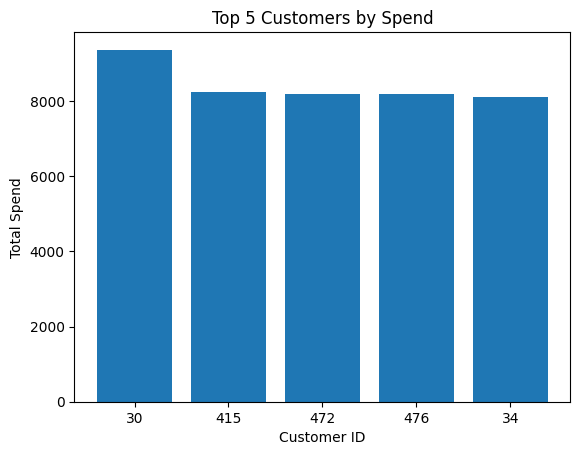

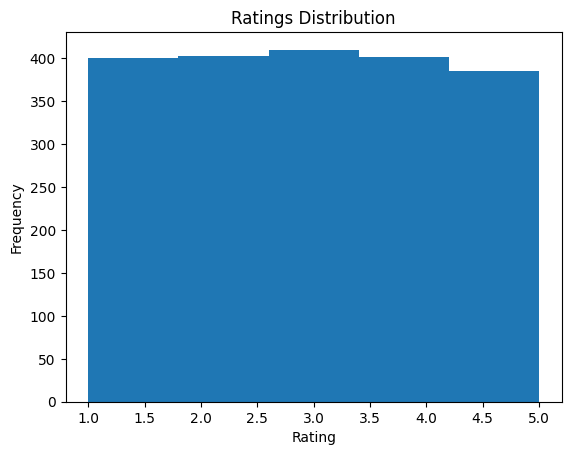

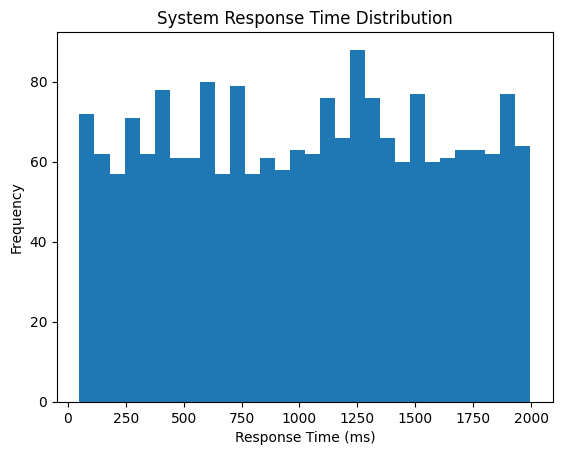


🔹 Data Integration Layer...

🔹 Storage Layer...
Data stored successfully

🔹 Consumption Layer (Insights)

🏆 Top 5 Customers:
     customer_id  total_price
28            30         9363
405          415         8247
462          472         8190
466          476         8186
32            34         8114

⚡ Avg Response Time (ms): 1025.86

⭐ Top Rated Products:
    product_id    rating
68         168  3.785714
22         122  3.687500
81         181  3.590909
96         196  3.578947
8          108  3.434783

📊 Customer 360 Sample:
   customer_id  total_price  order_count
0            1         1338            1
1            2         5959            7
2            3         2337            3
3            4          480            1
4            5          946            2

✅ Pipeline Execution Completed Successfully


In [ ]:
# ==========================================
# ENHANCED CLOUD DATA PIPELINE
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# 1. INGESTION LAYER
# ------------------------------
print("🔹 Ingestion Layer: Loading data sources...")

transactions = pd.read_csv("transactions_2000.csv")
logs = pd.read_csv("weblogs_2000.csv")
reviews = pd.read_csv("reviews_2000.csv")

print(f"Transactions: {transactions.shape}")
print(f"Logs: {logs.shape}")
print(f"Reviews: {reviews.shape}")

# ------------------------------
# 2. DATA QUALITY CHECKS
# ------------------------------
print("\n🔹 Data Quality Checks...")

transactions.dropna(inplace=True)
logs.dropna(inplace=True)
reviews.dropna(inplace=True)

print("Missing values removed")

# ------------------------------
# 3. PROCESSING LAYER
# ------------------------------
print("\n🔹 Processing Layer...")

transactions["total_price"] = transactions["quantity"] * transactions["price"]

transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])
logs["timestamp"] = pd.to_datetime(logs["timestamp"])
reviews["timestamp"] = pd.to_datetime(reviews["timestamp"])

# ------------------------------
# 4. ANALYTICS LAYER
# ------------------------------
print("\n🔹 Analytics Layer...")

customer_spend = transactions.groupby("customer_id")["total_price"].sum().reset_index()
top_customers = customer_spend.sort_values(by="total_price", ascending=False).head(5)

avg_response_time = logs["response_time_ms"].mean()
avg_rating = reviews.groupby("product_id")["rating"].mean().reset_index()

# ------------------------------
# 4.5 VISUALIZATION LAYER (QuickSight Simulation)
# ------------------------------
print("\n🔹 Visualization Layer...")

# Top Customers Bar Chart
plt.figure()
plt.bar(top_customers["customer_id"].astype(str), top_customers["total_price"])
plt.title("Top 5 Customers by Spend")
plt.xlabel("Customer ID")
plt.ylabel("Total Spend")
plt.show()

# Ratings Distribution
plt.figure()
plt.hist(reviews["rating"], bins=5)
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# Response Time Distribution
plt.figure()
plt.hist(logs["response_time_ms"], bins=30)
plt.title("System Response Time Distribution")
plt.xlabel("Response Time (ms)")
plt.ylabel("Frequency")
plt.show()

# ------------------------------
# 5. INTEGRATION (SIMULATING CUSTOMER 360)
# ------------------------------
print("\n🔹 Data Integration Layer...")

customer_orders = transactions.groupby("customer_id").size().reset_index(name="order_count")
customer_360 = pd.merge(customer_spend, customer_orders, on="customer_id")

# ------------------------------
# 6. STORAGE LAYER
# ------------------------------
print("\n🔹 Storage Layer...")

customer_360.to_csv("customer_360.csv", index=False)
avg_rating.to_csv("product_ratings.csv", index=False)

print("Data stored successfully")

# ------------------------------
# 7. CONSUMPTION LAYER
# ------------------------------
print("\n🔹 Consumption Layer (Insights)")

print("\n🏆 Top 5 Customers:")
print(top_customers)

print("\n⚡ Avg Response Time (ms):", round(avg_response_time, 2))

print("\n⭐ Top Rated Products:")
print(avg_rating.sort_values(by="rating", ascending=False).head(5))

print("\n📊 Customer 360 Sample:")
print(customer_360.head())

print("\n✅ Pipeline Execution Completed Successfully")